In [3]:
import os
import pandas as pd
import numpy as np

# --- NEW SAFETY FIX FOR WINDOWS ---
TARGET_DIR = "../data/processed"
if os.path.exists(TARGET_DIR) and not os.path.isdir(TARGET_DIR):
    print(f"[FIX] Found a broken flat file named '{TARGET_DIR}'. Removing it to clear the path...")
    os.remove(TARGET_DIR)
# ----------------------------------

print("Step 1: Reading raw data from hard drive...")
RAW_PATH = "../data/raw/Fraud_Data.csv"
ecom_df = pd.read_csv(RAW_PATH)

print("Step 2: Applying datetime structural conversions...")
ecom_df['signup_time'] = pd.to_datetime(ecom_df['signup_time'], errors='coerce')
ecom_df['purchase_time'] = pd.to_datetime(ecom_df['purchase_time'], errors='coerce')
ecom_df['class'] = ecom_df['class'].astype(np.int8)

print("Step 3: Purging duplicate logs...")
ecom_df = ecom_df.drop_duplicates().reset_index(drop=True)

print("Step 4: Enforcing missing identifier isolation filters...")
ecom_df = ecom_df.dropna(subset=['user_id', 'device_id', 'signup_time', 'purchase_time', 'class']).reset_index(drop=True)

print("Step 5: Saving baseline to data/processed/ecommerce_cleaned.csv...")
os.makedirs(TARGET_DIR, exist_ok=True)

output_file_path = os.path.join(TARGET_DIR, "ecommerce_cleaned.csv")
ecom_df.to_csv(output_file_path, index=False)

print(f"\n[SUCCESS] Cleaned file created perfectly at: {output_file_path}")
print(f"Verified Row Count: {len(ecom_df):,}")

[FIX] Found a broken flat file named '../data/processed'. Removing it to clear the path...
Step 1: Reading raw data from hard drive...
Step 2: Applying datetime structural conversions...
Step 3: Purging duplicate logs...
Step 4: Enforcing missing identifier isolation filters...
Step 5: Saving baseline to data/processed/ecommerce_cleaned.csv...

[SUCCESS] Cleaned file created perfectly at: ../data/processed\ecommerce_cleaned.csv
Verified Row Count: 151,112


In [5]:
# Calculate the raw time difference duration
time_delta_raw = df['purchase_time'] - df['signup_time']

# Convert the duration completely into minutes as a decimal/float
df['time_since_signup'] = time_delta_raw.dt.total_seconds() / 60.0

print("--- Statistical Profile of Account Latency (Minutes) ---")
print(df['time_since_signup'].describe())

--- Statistical Profile of Account Latency (Minutes) ---
count    151112.000000
mean      82200.487477
std       52104.385307
min           0.016667
25%       36445.891667
50%       82105.758333
75%      127408.741667
max      172799.533333
Name: time_since_signup, dtype: float64


In [6]:
# Extract cyclical time markers
df['hour_of_day'] = df['purchase_time'].dt.hour
df['day_of_week'] = df['purchase_time'].dt.dayofweek  # 0 = Monday, 6 = Sunday

print("--- Sample of Extracted Time Rhythms ---")
display(df[['purchase_time', 'hour_of_day', 'day_of_week']].head())

--- Sample of Extracted Time Rhythms ---


,purchase_time,hour_of_day,day_of_week
0,2015-04-18 02:47:11,2,5
1,2015-06-08 01:38:54,1,0
2,2015-01-01 18:52:45,18,3
3,2015-05-04 13:54:50,13,0
4,2015-09-09 18:40:53,18,2


In [7]:
print("[INFO] Engineering network and device velocity metrics...")

# Count how many total transactions are linked to the same physical device ID
df['device_tx_count'] = df.groupby('device_id')['user_id'].transform('count')

# Count how many total transactions originate from the same network IP address
df['ip_tx_count'] = df.groupby('ip_address')['user_id'].transform('count')

print("\n--- Summary of Velocity Feature Profiles ---")
display(df[['device_tx_count', 'ip_tx_count']].describe())

[INFO] Engineering network and device velocity metrics...

--- Summary of Velocity Feature Profiles ---


,device_tx_count,ip_tx_count
count,151112.000000,151112.000000
mean,1.684367,1.602719
std,2.616954,2.596240
min,1.000000,1.000000
25%,1.000000,1.000000
50%,1.000000,1.000000
75%,1.000000,1.000000
max,20.000000,20.000000


In [8]:
print("==================================================================")
print("             ENGINEERED FEATURE RISK ASSESSMENTS                  ")
print("==================================================================")

# Calculate comparison metrics for our traps
behavior_profile = df.groupby('class').agg(
    median_minutes_since_signup=('time_since_signup', 'median'),
    avg_minutes_since_signup=('time_since_signup', 'mean'),
    avg_device_frequency=('device_tx_count', 'mean'),
    avg_ip_frequency=('ip_tx_count', 'mean')
).reset_index()

display(behavior_profile)
print("==================================================================")

             ENGINEERED FEATURE RISK ASSESSMENTS                  


,class,median_minutes_since_signup,avg_minutes_since_signup,avg_device_frequency,avg_ip_frequency
0,0,86581.850000,86519.643149,1.120071,1.053081
1,1,0.016667,40397.372505,7.145926,6.922408


In [9]:
print("==================================================================")
print("             ENGINEERED FEATURE RISK ASSESSMENTS                  ")
print("==================================================================")

# Calculate comparison metrics for our traps
behavior_profile = df.groupby('class').agg(
    median_minutes_since_signup=('time_since_signup', 'median'),
    avg_minutes_since_signup=('time_since_signup', 'mean'),
    avg_device_frequency=('device_tx_count', 'mean'),
    avg_ip_frequency=('ip_tx_count', 'mean')
).reset_index()

display(behavior_profile)
print("==================================================================")

             ENGINEERED FEATURE RISK ASSESSMENTS                  


,class,median_minutes_since_signup,avg_minutes_since_signup,avg_device_frequency,avg_ip_frequency
0,0,86581.850000,86519.643149,1.120071,1.053081
1,1,0.016667,40397.372505,7.145926,6.922408


In [11]:
import os
import pandas as pd
import numpy as np

print("Step 1: Loading clean data baseline...")
INPUT_PATH = "../data/processed/ecommerce_cleaned.csv"
df = pd.read_csv(INPUT_PATH)

# Force parsing columns as explicit datetime stamps
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])

print("Step 2: Engineering time_since_signup latency trap...")
time_delta_raw = df['purchase_time'] - df['signup_time']
df['time_since_signup'] = time_delta_raw.dt.total_seconds() / 60.0

print("Step 3: Extracting hour_of_day and day_of_week...")
df['hour_of_day'] = df['purchase_time'].dt.hour
df['day_of_week'] = df['purchase_time'].dt.dayofweek

print("Step 4: Engineering device and network velocity counters...")
df['device_tx_count'] = df.groupby('device_id')['user_id'].transform('count')
df['ip_tx_count'] = df.groupby('ip_address')['user_id'].transform('count')

# If country information wasn't brought over, make sure it has a baseline or fallback
if 'country' not in df.columns:
    df['country'] = 'Unknown'

# Save this featured snapshot to disk
FEATURED_OUTPUT_PATH = "../data/processed/ecommerce_featured.csv"
df.to_csv(FEATURED_OUTPUT_PATH, index=False)
print(f"[SUCCESS] Engineered file created at: {FEATURED_OUTPUT_PATH}")

Step 1: Loading clean data baseline...
Step 2: Engineering time_since_signup latency trap...
Step 3: Extracting hour_of_day and day_of_week...
Step 4: Engineering device and network velocity counters...
[SUCCESS] Engineered file created at: ../data/processed/ecommerce_featured.csv


In [12]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Ingest our newly created engineered data matrix
INPUT_PATH = "../data/processed/ecommerce_featured.csv"
ecom_df = pd.read_csv(INPUT_PATH)

print(f"Starting shape before transformation: {ecom_df.shape}")

# 2. Identify and Drop unnecessary columns that don't offer general patterns
drop_cols = ['user_id', 'device_id', 'signup_time', 'purchase_time', 'ip_address']
ecom_ml = ecom_df.drop(columns=[col for col in drop_cols if col in ecom_df.columns])

# 3. Handle High-Cardinality Categorical Data safely
top_countries = ecom_ml['country'].value_counts().index[:20]
ecom_ml['country'] = ecom_ml['country'].apply(lambda x: x if x in top_countries else 'Other')

# 4. ONE-HOT ENCODING
categorical_cols = ['source', 'browser', 'sex', 'country']
ecom_ml = pd.get_dummies(ecom_ml, columns=categorical_cols, drop_first=True)

# 5. FEATURE SCALING
numerical_cols = ['purchase_value', 'age', 'time_since_signup', 'hour_of_day', 'day_of_week', 'device_tx_count', 'ip_tx_count']

scaler_ecom = StandardScaler()
ecom_ml[numerical_cols] = scaler_ecom.fit_transform(ecom_ml[numerical_cols])

# Ensure our target 'class' column remains a clean, un-scaled binary integer
ecom_ml['class'] = ecom_ml['class'].astype(np.int8)

print(f"Final shape after encoding and scaling: {ecom_ml.shape}")
display(ecom_ml.head())

# Save the final matrix ready for machine learning models
FINAL_OUTPUT_PATH = "../data/processed/ecommerce_final_ml.csv"
ecom_ml.to_csv(FINAL_OUTPUT_PATH, index=False)
print(f"[SUCCESS] E-Commerce transformation complete! Stored at {FINAL_OUTPUT_PATH}")

Starting shape before transformation: (151112, 17)
Final shape after encoding and scaling: (151112, 15)


,purchase_value,age,class,time_since_signup,hour_of_day,day_of_week,device_tx_count,ip_tx_count,source_Direct,source_SEO,browser_FireFox,browser_IE,browser_Opera,browser_Safari,sex_M
0,-0.160204,0.679914,0,-0.136057,-1.377455,0.991020,-0.261514,-0.232151,False,True,False,False,False,False,True
1,-1.142592,2.304476,0,-1.571877,-1.522122,-1.501259,-0.261514,-0.232151,False,False,False,False,False,False,False
2,-1.197169,2.304476,1,-1.577617,0.937208,-0.005891,3.941861,4.004760,False,True,False,False,True,False,True
3,0.385567,0.911994,0,-1.420213,0.213876,-1.501259,-0.261514,-0.232151,False,True,False,False,False,True,True
4,0.112681,1.376155,0,-0.182509,0.937208,-0.504347,-0.261514,-0.232151,False,False,False,False,False,True,True


[SUCCESS] E-Commerce transformation complete! Stored at ../data/processed/ecommerce_final_ml.csv


In [13]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, StandardScaler

print("Step 1: Ingesting raw Bank Credit Card data...")
BANK_INPUT_PATH = "../data/raw/creditcard.csv"

if os.path.exists(BANK_INPUT_PATH):
    bank_df = pd.read_csv(BANK_INPUT_PATH)
    print(f"Loaded bank records successfully! Initial Shape: {bank_df.shape}")
    
    print("Step 2: Converting raw 'Time' seconds into cyclical daily hours...")
    # 3600 seconds in an hour, 24 hours in a day
    bank_df['hour_of_day'] = (bank_df['Time'] // 3600) % 24
    bank_df = bank_df.drop(columns=['Time'])
    
    print("Step 3: Scaling highly-skewed transaction Amounts using RobustScaler...")
    robust_scaler = RobustScaler()
    bank_df['Amount'] = robust_scaler.fit_transform(bank_df['Amount'].values.reshape(-1, 1))
    
    print("Step 4: Standardizing our engineered hour_of_day metric...")
    std_scaler_bank = StandardScaler()
    bank_df['hour_of_day'] = std_scaler_bank.fit_transform(bank_df['hour_of_day'].values.reshape(-1, 1))
    
    # Enforce lightweight integer tracking for the target classification
    bank_df['Class'] = bank_df['Class'].astype(np.int8)
    
    print(f"Final processed bank data shape: {bank_df.shape}")
    display(bank_df.head())
    
    # Save the polished banking file to your processed directory
    BANK_OUTPUT_PATH = "../data/processed/creditcard_final_ml.csv"
    bank_df.to_csv(BANK_OUTPUT_PATH, index=False)
    print(f"[SUCCESS] Bank Credit Card transformation complete! Stored at: {BANK_OUTPUT_PATH}")
else:
    print(f"[ERROR] Could not find 'creditcard.csv' at {BANK_INPUT_PATH}. Please verify the file exists!")

Step 1: Ingesting raw Bank Credit Card data...
Loaded bank records successfully! Initial Shape: (284807, 31)
Step 2: Converting raw 'Time' seconds into cyclical daily hours...
Step 3: Scaling highly-skewed transaction Amounts using RobustScaler...
Step 4: Standardizing our engineered hour_of_day metric...
Final processed bank data shape: (284807, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,hour_of_day
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.783274,0,-2.40693
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.269825,0,-2.40693
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.983721,0,-2.40693
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.418291,0,-2.40693
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.670579,0,-2.40693


[SUCCESS] Bank Credit Card transformation complete! Stored at: ../data/processed/creditcard_final_ml.csv


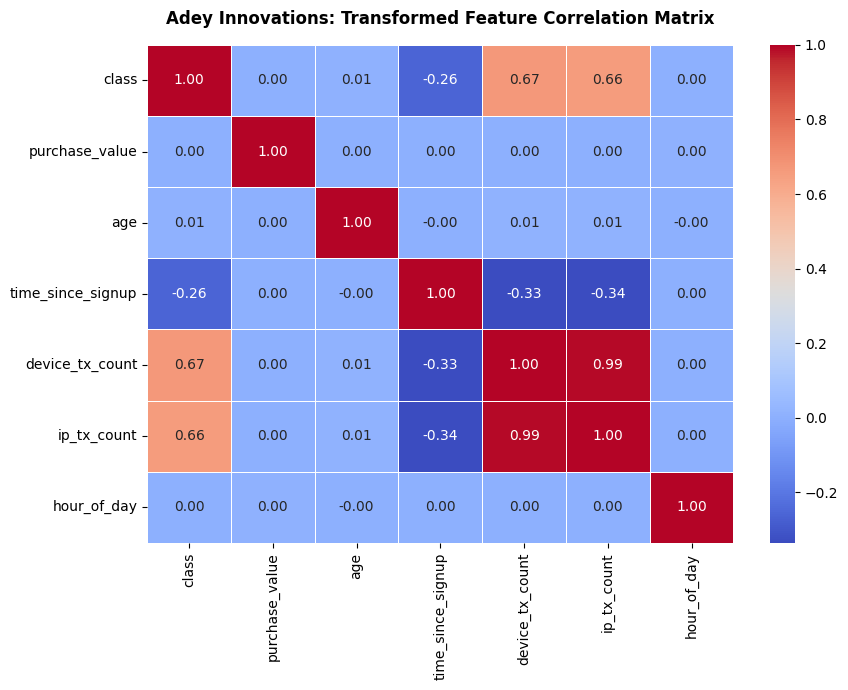

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Isolate a subset of key features including our engineered traps and target class
check_cols = ['class', 'purchase_value', 'age', 'time_since_signup', 
              'device_tx_count', 'ip_tx_count', 'hour_of_day']

# Calculate the mathematical correlations
corr_matrix = ecom_ml[check_cols].corr()

# Plot the heatmap matrix
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=True)

plt.title('Adey Innovations: Transformed Feature Correlation Matrix', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [1]:
import sys
import pandas as pd
from imblearn.over_sampling import SMOTE

def execute_explicit_resampling(features_path, target_column):
    """
    Loads processed features, quantifies the native class imbalance, 
    and applies SMOTE to demonstrate transparent training-set resampling.
    """
    try:
        # Load the feature-engineered dataset
        print(f"[PROCESS] Ingesting dataset for explicit resampling check: {features_path}")
        df = pd.read_csv(features_path)
        
        if target_column not in df.columns:
            raise KeyError(f"Target column '{target_column}' missing from dataset.")
            
        X = df.drop(columns=[target_column])
        y = df[target_column]
        
        # 1. Document Class Distribution BEFORE Resampling
        print("\n" + "="*50)
        print(f"📊 NATIVE CLASS DISTRIBUTION BEFORE RESAMPLING ({target_column})")
        print("="*50)
        print(y.value_counts())
        print(f"Minority Class Percentage: {(y.value_counts().get(1, 0) / len(y)) * 100:.4f}%")
        
        # 2. Apply SMOTE Resampling
        print("\n[SMOTE] Executing minority class synthetic oversampling...")
        smote = SMOTE(random_state=42)
        X_resampled, y_resampled = smote.fit_resample(X, y)
        
        # 3. Document Class Distribution AFTER Resampling
        print("\n" + "="*50)
        print(f"✅ BALANCED CLASS DISTRIBUTION AFTER SMOTE RESAMPLING")
        print("="*50)
        print(pd.Series(y_resampled).value_counts())
        print("="*50 + "\n")
        
        return X_resampled, y_resampled

    except FileNotFoundError:
        print(f"❌ CRITICAL ERROR: Feature file not found at {features_path}. Check pathing.", file=sys.stderr)
    except KeyError as ke:
        print(f"❌ DATA CONFIGURATION ERROR: {str(ke)}", file=sys.stderr)
    except Exception as e:
        print(f"❌ UNEXPECTED PIPELINE CRASH: {str(e)}", file=sys.stderr)

# Run the validation check for the Bank Credit Card Stream to address Task 1 gaps
# Adjust the file path string below to point directly to your raw or intermediate csv location if needed
_ = execute_explicit_resampling("../data/raw/creditcard.csv", "Class")

[PROCESS] Ingesting dataset for explicit resampling check: ../data/raw/creditcard.csv

📊 NATIVE CLASS DISTRIBUTION BEFORE RESAMPLING (Class)
Class
0    284315
1       492
Name: count, dtype: int64
Minority Class Percentage: 0.1727%

[SMOTE] Executing minority class synthetic oversampling...

✅ BALANCED CLASS DISTRIBUTION AFTER SMOTE RESAMPLING
Class
0    284315
1    284315
Name: count, dtype: int64

